In [1]:
from transformers import Owlv2Processor, Owlv2ForObjectDetection
from PIL import Image
import torch


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
MODEL_NAME = "google/owlv2-base-patch16-ensemble"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
processor = Owlv2Processor.from_pretrained(MODEL_NAME)
model = Owlv2ForObjectDetection.from_pretrained(MODEL_NAME).to(DEVICE)

In [11]:
support_img = Image.open(r"E:\Hachix\data\mounting_nock\nock\20251212163421_C1.jpeg").convert("RGB")
query_img = Image.open(r"E:\Hachix\data\mounting_nock\nock\20251212165351_C1.jpeg").convert("RGB")

In [ ]:
support_bbox = [[0.15698, 0.36673, 0.09898, 0.21243]] # normalized bbox [cx, cy, w, h]

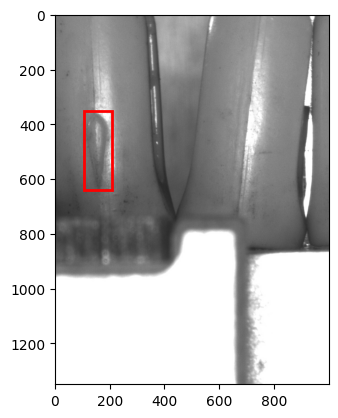

In [13]:
# Plot support image with bbox

fig, ax = plt.subplots(1)
ax.imshow(support_img)
for bbox in support_bbox:
    x_center, y_center, width, height = bbox
    img_width, img_height = support_img.size
    rect = patches.Rectangle(
        ( (x_center - width / 2) * img_width, (y_center - height / 2) * img_height ),
        width * img_width,
        height * img_height,
        linewidth=2,
        edgecolor="r",
        facecolor="none"
    )
    ax.add_patch(rect)
plt.show()

In [14]:
inputs = processor(
    images=[query_img],
    text=None,
    # few-shot support data:
    negative_images=None,
    positive_images=[support_img],
    positive_boxes=[support_bbox],
    return_tensors="pt"
).to(DEVICE)

Unused or unrecognized kwargs: negative_images, positive_images, positive_boxes.


In [15]:
with torch.no_grad():
    outputs = model(**inputs)

TypeError: Owlv2ForObjectDetection.forward() missing 1 required positional argument: 'input_ids'